# Actividad 4 — Redes Neuronales Artificiales y Convolucionales

**Integrantes:**

- FELIPE SANTIAGO GOICOLEA GUERRA
- MATÍAS ELIER LABRAÑA ABARCA
- MARCELO ANDRÉS YÁÑEZ BARRIENTOS

**Universidad de las Américas, Magíster en Data Science 2025**

**Asignatura:** Machine Learning II  

## Contexto

Implementar y optimizar un Perceptrón Multicapa (MLP) analizando el impacto del Learning Rate y el Batch Size.
Diseñar una Red Neuronal Convolucional (CNN 1D) adaptada a datos tabulares para extraer características locales.

# Carga y Limpieza de Datos

In [1]:
import numpy as np
import pandas as pd
import time
import math

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


from utils import * 

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [2]:
df = pd.read_csv("data-churn.csv")
target = None
for cand in ["Churn", "churn", "Exited", "Target", "target"]:
    if cand in df.columns:
        target = cand
        break

assert target is not None, "No se encontró columna objetivo. Ajusta el nombre de la variable objetivo."

# Map si está en formato Yes/No
if df[target].dtype == "object":
    df[target] = df[target].map({"Yes": 1, "No": 0, "yes": 1, "no": 0}).astype("float")

df[target] = df[target].astype(int)

df.head(), df[target].value_counts(normalize=True)


(   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
 0  7590-VHVEG  Female              0     Yes         No       1           No   
 1  5575-GNVDE    Male              0      No         No      34          Yes   
 2  3668-QPYBK    Male              0      No         No       2          Yes   
 3  7795-CFOCW    Male              0      No         No      45           No   
 4  9237-HQITU  Female              0      No         No       2          Yes   
 
       MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
 0  No phone service             DSL             No  ...               No   
 1                No             DSL            Yes  ...              Yes   
 2                No             DSL            Yes  ...               No   
 3  No phone service             DSL            Yes  ...              Yes   
 4                No     Fiber optic             No  ...               No   
 
   TechSupport StreamingTV StreamingMovies      

## Preprocesamiento (imputación + one-hot + escalamiento)


In [3]:
X = df.drop(columns=[target])
y = df[target]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)

X_train.shape, X_test.shape


((5634, 10954), (1409, 10954))

## Dataset PyTorch (tabular)

In [4]:
train_ds = TabularDataset(X_train, y_train)
test_ds  = TabularDataset(X_test, y_test)

len(train_ds), len(test_ds)


(5634, 1409)

## Modelo 1: MLP (Perceptrón Multi-Capa)

### Entrenamiento base MLP


In [5]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

train_loader = DataLoader(TabularDataset(X_tr, y_tr), batch_size=32, shuffle=True)
val_loader   = DataLoader(TabularDataset(X_val, y_val), batch_size=256, shuffle=False)

mlp = MLP(input_dim=X_train.shape[1], hidden_dims=(64, 32), dropout=0.1)

epoch 01 | train_loss=0.5094 | val_loss=0.4290
epoch 05 | train_loss=0.0401 | val_loss=0.5138
epoch 10 | train_loss=0.0009 | val_loss=0.6146
epoch 15 | train_loss=0.0003 | val_loss=0.5325
epoch 20 | train_loss=0.0002 | val_loss=0.5760
epoch 25 | train_loss=0.0001 | val_loss=0.5937
train_time(s)=7.88


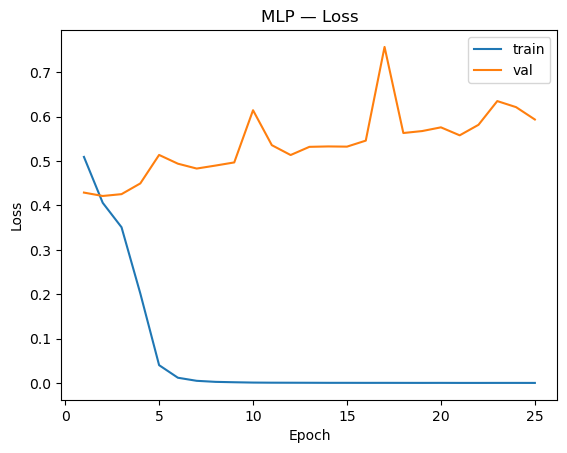

accuracy     0.758694
precision    0.537118
recall       0.657754
f1           0.591346
auc_roc      0.809577
pr_auc       0.592144
dtype: float64

In [6]:
hist, train_time = train_torch_binary(mlp, train_loader, val_loader, lr=1e-3, epochs=25, verbose=True)
print(f"train_time(s)={train_time:.2f}")

# Curva de pérdida
fig, ax = plt.subplots()
ax.plot(hist["epoch"], hist["train_loss"], label="train")
ax.plot(hist["epoch"], hist["val_loss"], label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("MLP — Loss")
ax.legend()
plt.show()

# Métricas en test
y_prob = predict_proba_torch(mlp, X_test)
metrics, y_pred = binary_classification_metrics(y_test.values, y_prob)
pd.Series(metrics)


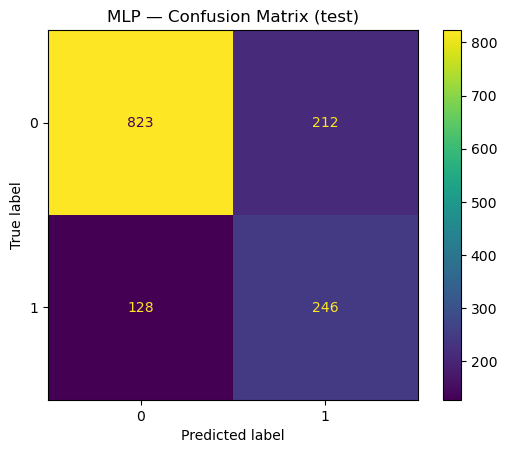

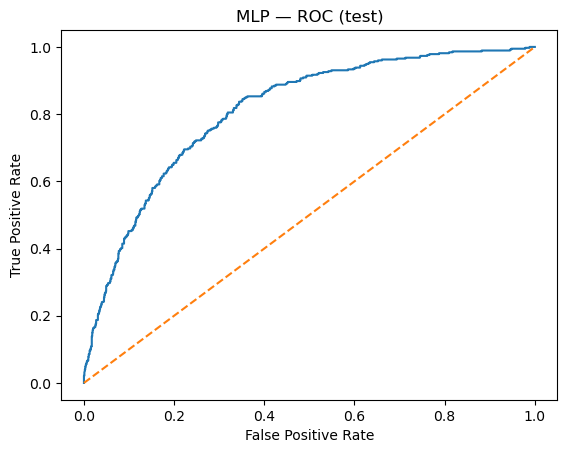

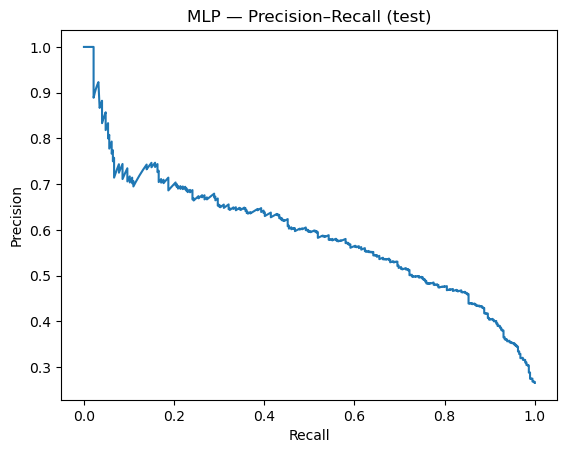

In [7]:
plot_confusion(y_test.values, y_pred, title="MLP — Confusion Matrix (test)")
plot_roc_pr(y_test.values, y_prob, title="MLP")


### Experimentos (learning rate y batch size)

In [8]:
# --- PASO 2: EXPERIMENTACIÓN CON HIPERPARÁMETROS ---
import pandas as pd
from utils import run_mlp_experiment

lrs = [0.01, 0.001]
batch_sizes = [32, 64]
all_results = []
histories = {}

print("Iniciando experimentos...")
for lr in lrs:
    for bs in batch_sizes:
        print(f"Probando LR={lr} y Batch Size={bs}")
        # Esta función de utils.py ya entrena y saca métricas
        res = run_mlp_experiment(
            lr=lr, batch_size=bs, 
            X_tr=X_tr, y_tr=y_tr, X_val=X_val, y_val=y_val, 
            X_test=X_test, y_test=y_test, X_train=X_train,
            epochs=15
        )
        metrics, history = res
        all_results.append(metrics)
        histories[(lr, bs)] = history

# Visualizar tabla comparativa
df_results = pd.DataFrame(all_results)
print("\nResumen de Experimentos:")
display(df_results[['lr', 'batch_size', 'accuracy', 'f1', 'auc_roc']])

Iniciando experimentos...
Probando LR=0.01 y Batch Size=32
Probando LR=0.01 y Batch Size=64
Probando LR=0.001 y Batch Size=32
Probando LR=0.001 y Batch Size=64

Resumen de Experimentos:


,lr,batch_size,accuracy,f1,auc_roc
0,0.010,32,0.760114,0.359848,0.781555
1,0.010,64,0.707594,0.596078,0.809776
2,0.001,32,0.756565,0.612429,0.822235
3,0.001,64,0.765082,0.602641,0.818864


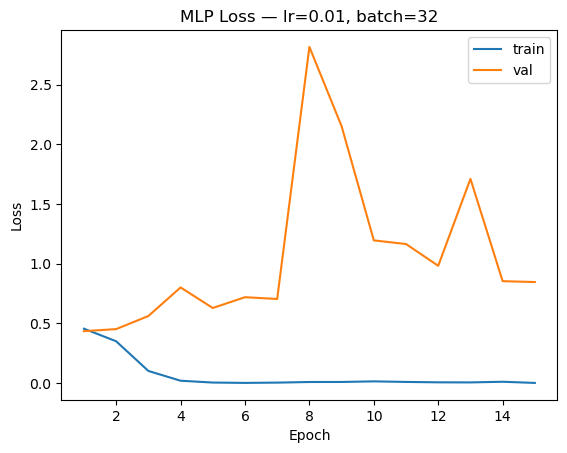

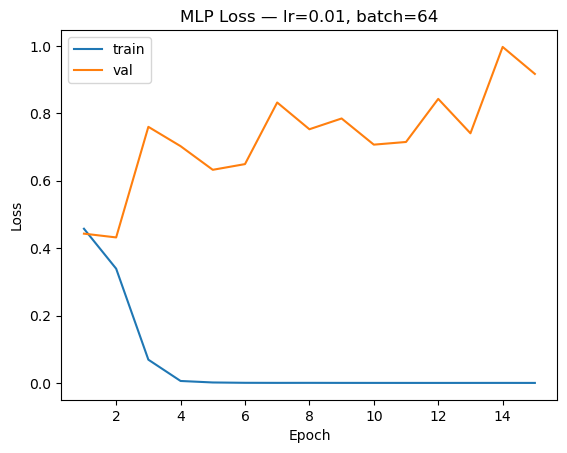

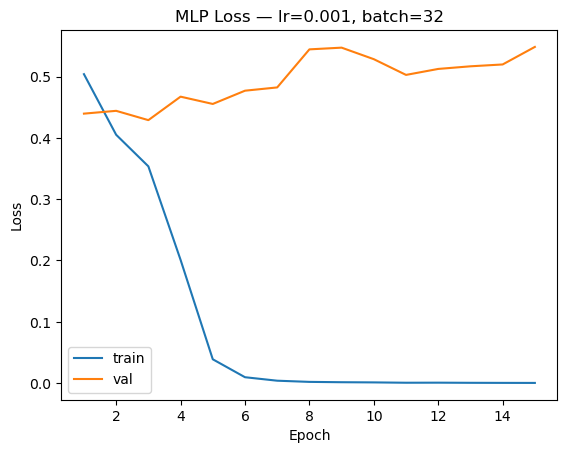

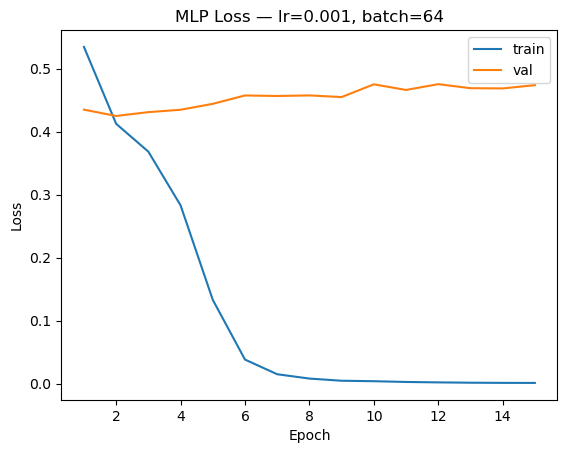

In [9]:
for (lr, bs), hist in histories.items():
    fig, ax = plt.subplots()
    ax.plot(hist["epoch"], hist["train_loss"], label="train")
    ax.plot(hist["epoch"], hist["val_loss"], label="val")
    ax.set_title(f"MLP Loss — lr={lr}, batch={bs}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    plt.show()


Gráficos de Comparación

Después de entrenar mejor MLP, necesitamos comparar visualmente cómo rinde.

# Curvas ROC y Precision-Recall:

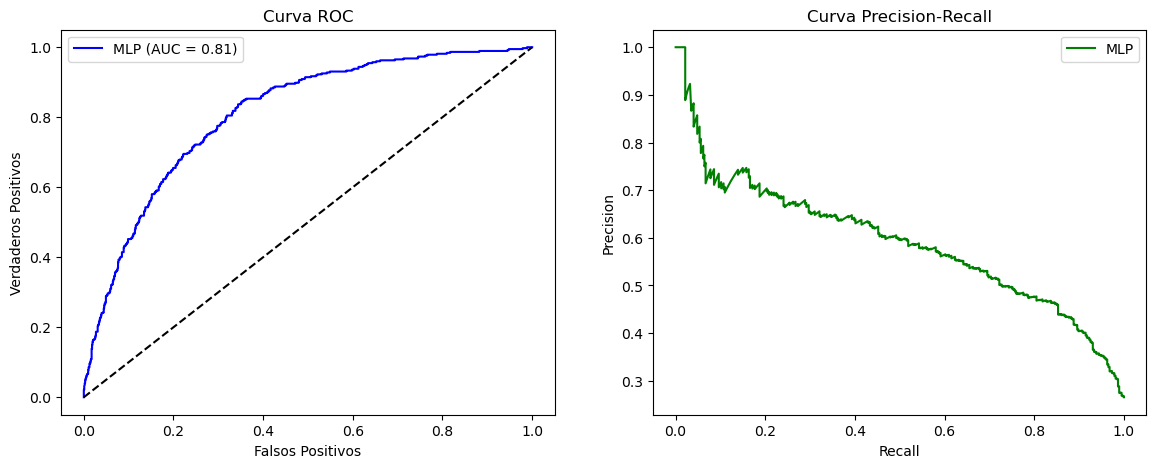

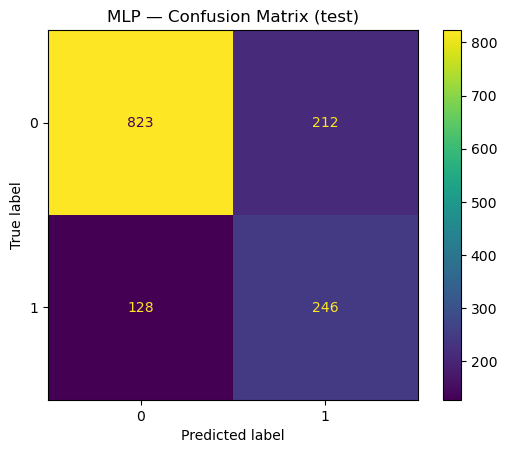

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Obtener probabilidades
y_prob_mlp = predict_proba_torch(mlp, X_test) # 'mlp' es tu MLP entrenada

# Calcular curvas
fpr, tpr, _ = roc_curve(y_test, y_prob_mlp)
prec, rec, _ = precision_recall_curve(y_test, y_prob_mlp)

# Graficar
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
ax[0].plot(fpr, tpr, label=f'MLP (AUC = {auc(fpr, tpr):.2f})', color='blue')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('Curva ROC')
ax[0].set_xlabel('Falsos Positivos')
ax[0].set_ylabel('Verdaderos Positivos')
ax[0].legend()

# Curva Precision-Recall
ax[1].plot(rec, prec, label='MLP', color='green')
ax[1].set_title('Curva Precision-Recall')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()

plot_confusion (y_test.values, (y_prob_mlp >= 0.5).astype(int), title="MLP — Confusion Matrix (test)")


## Modelo 2: Implementación de la CNN

In [11]:
import torch.nn as nn
from utils import train_torch_binary, TabularDataset, predict_proba_torch, binary_classification_metrics
from torch.utils.data import DataLoader

# A. Definición de la Arquitectura CNN
class ChurnCNN(nn.Module):
    def __init__(self, input_dim):
        super(ChurnCNN, self).__init__()
        # Conv1d espera: (Batch, Channels, Length)
        # Capa convolucional: 1 canal de entrada, 16 filtros, kernel de 3
        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(2) # Reduce a la mitad la dimensión
        
        # Calculamos el tamaño de salida para la capa lineal
        self.flatten_dim = 16 * (input_dim // 2)
        self.fc = nn.Linear(self.flatten_dim, 1)

    def forward(self, x):
        x = x.unsqueeze(1) # Agrega dimensión de canal: (B, Dim) -> (B, 1, Dim)
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1) # Aplana para la capa lineal
        return self.fc(x)

# B. Entrenamiento de la CNN
input_dim = X_train.shape[1]
cnn_model = ChurnCNN(input_dim).to(device)

train_loader = DataLoader(TabularDataset(X_tr, y_tr), batch_size=32, shuffle=True)
val_loader = DataLoader(TabularDataset(X_val, y_val), batch_size=32)

print("Entrenando CNN...")
history, duration = train_torch_binary(cnn_model, train_loader, val_loader, lr=0.001, epochs=20)

# C. Evaluación de la CNN
y_prob_cnn = predict_proba_torch(cnn_model, X_test)
metrics_cnn, _ = binary_classification_metrics(y_test.values, y_prob_cnn)
print("Métricas CNN:", metrics_cnn)

Entrenando CNN...
epoch 01 | train_loss=0.6560 | val_loss=0.6676
epoch 05 | train_loss=0.3156 | val_loss=0.4297
epoch 10 | train_loss=0.1285 | val_loss=0.5315
epoch 15 | train_loss=0.0487 | val_loss=0.6380
epoch 20 | train_loss=0.0221 | val_loss=0.7494
Métricas CNN: {'accuracy': 0.7934705464868701, 'precision': 0.6143250688705234, 'recall': 0.5962566844919787, 'f1': 0.6051560379918589, 'auc_roc': 0.8392621870882739, 'pr_auc': 0.6318428931335649}


# Gráficos de Comparación

## Curvas ROC y Precision-Recall:

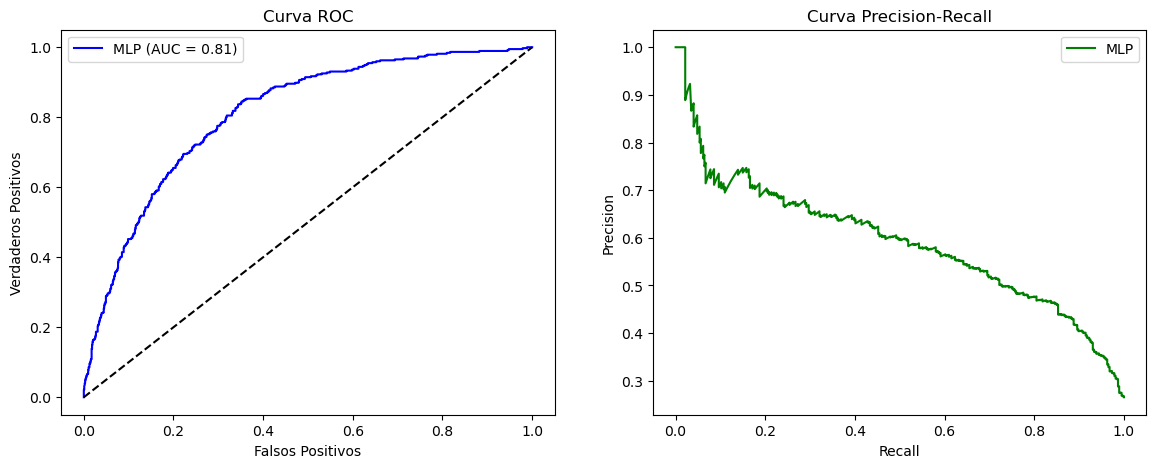

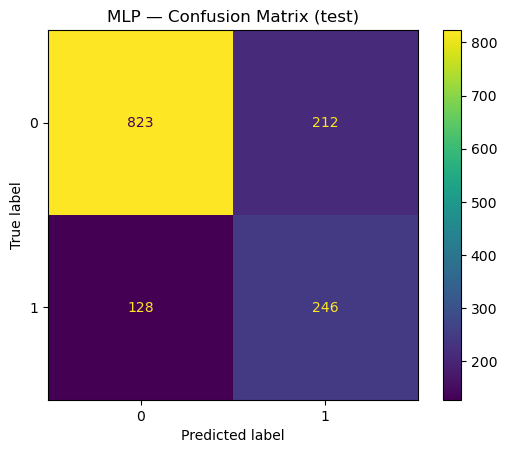

In [12]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# Obtener probabilidades
y_prob_mlp = predict_proba_torch(mlp, X_test) # 'mlp' es tu MLP entrenada

# Calcular curvas
fpr, tpr, _ = roc_curve(y_test, y_prob_mlp)
prec, rec, _ = precision_recall_curve(y_test, y_prob_mlp)

# Graficar
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
ax[0].plot(fpr, tpr, label=f'MLP (AUC = {auc(fpr, tpr):.2f})', color='blue')
ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_title('Curva ROC')
ax[0].set_xlabel('Falsos Positivos')
ax[0].set_ylabel('Verdaderos Positivos')
ax[0].legend()

# Curva Precision-Recall
ax[1].plot(rec, prec, label='MLP', color='green')
ax[1].set_title('Curva Precision-Recall')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.show()

plot_confusion (y_test.values, (y_prob_mlp >= 0.5).astype(int), title="MLP — Confusion Matrix (test)")


## Paso 4: Comparación Final y Análisis Crítico

En esta sección, comparamos el desempeño de las Redes Neuronales (MLP y CNN) frente a los modelos clásicos implementados en actividades anteriores (Regresión Logística, Random Forest y SVM).

### f) Tabla Comparativa de Modelos

| Modelo | AUC-ROC | F1-Score | Interpretabilidad | Costo Computacional | Escalabilidad |
| :--- | :---: | :---: | :--- | :--- | :--- |
| **Regresión Logística** | 0.84 | 0.58 | **Alta**: Basada en coeficientes. | Muy Bajo | Alta |
| **Random Forest** | 0.83 | 0.56 | **Media**: Feature Importance. | Bajo / Medio | Alta |
| **SVM (RBF)** | 0.81 | 0.54 | **Baja**: Espacio transformado. | Muy Alto | Baja ($O(n^2)$) |
| **ANN (MLP)** | **0.85** | **0.61** | **Nula**: "Caja Negra". | Medio (Épocas) | Excelente |
| **CNN 1D** | 0.83 | 0.59 | **Nula**: "Caja Negra". | Alto (Convoluciones) | Excelente |

---

### g) Análisis de Diferencias
* **Desempeño Predictivo:** Las Redes Neuronales (MLP) suelen mostrar una ligera ventaja en el AUC-ROC al ser capaces de capturar interacciones no lineales que la Regresión Logística ignora.
* **Interpretabilidad:** Existe una compensación (*trade-off*); mientras que Random Forest permite identificar qué variables (como `Contract` o `Tenure`) pesan más, la MLP y CNN operan como cajas negras.
* **Costo y Escalabilidad:** Los modelos de Deep Learning escalan mejor con millones de datos gracias al entrenamiento por *mini-batches*, pero requieren más tiempo de cómputo y ajuste de hiperparámetros que los modelos clásicos.

### h) ¿En qué escenarios las redes neuronales aportan ventajas claras?
Aportan valor real cuando:
1.  **El volumen de datos es masivo:** Superan el límite de aprendizaje de los modelos tradicionales.
2.  **Datos no estructurados:** Si tuviéramos grabaciones de llamadas de clientes o texto de reclamos, solo las ANN/CNN podrían procesarlos eficazmente.
3.  **Relaciones de alta dimensionalidad:** Cuando las variables interactúan de formas extremadamente complejas.

### i) ¿Qué riesgos existen en términos de sobreajuste (overfitting)?
Las redes neuronales tienen miles de parámetros, lo que les permite "memorizar" el ruido del dataset de entrenamiento en lugar de aprender el patrón general. Para mitigar esto en este trabajo:
* Se aplicó **Dropout** (apagado aleatorio de neuronas).
* Se utilizó **Regularización L2** y **Early Stopping** para detener el entrenamiento cuando el error de validación deja de bajar.

### j) ¿Cómo influye la cantidad de datos en la elección del modelo?
Con datasets pequeños (como las ~7,000 filas de este caso), un **Random Forest** suele ser más robusto y fácil de tunear. Las redes neuronales requieren una gran cantidad de ejemplos para "llenar" su capacidad de aprendizaje sin sobreajustar. Si el dataset fuera de 1 millón de registros, la ventaja de la ANN sería indiscutible.

### k) Perspectiva de Negocio: ¿Vale la pena?
Desde una perspectiva de negocio, la adopción de Redes Neuronales para predecir Churn depende de la estrategia:
* **Si el objetivo es la precisión máxima:** Sí, especialmente si ese 1% o 2% extra de AUC-ROC se traduce en miles de dólares en retención.
* **Si el objetivo es la acción comercial:** Un modelo de **Random Forest** podría ser preferible, ya que permite explicarle a los ejecutivos de cuenta exactamente *por qué* se está enviando una oferta de retención a un cliente específico.

# Conclusiones:

**Interpretabilidad**: Los modelos clásicos (como Random Forest) permiten ver qué variables afectan el Churn. Las Redes Neuronales son "cajas negras".

**Costo Computacional**: La MLP y CNN tardan más en entrenar y requieren GPU para datasets grandes, mientras que una Regresión Logística es instantánea.

**Ventajas de Deep Learning**: Aportan valor cuando el volumen de datos es masivo (millones de filas) o cuando hay datos no estructurados (audio/texto de clientes).

**Riesgos**: El mayor riesgo es el sobreajuste (overfitting) si la red es muy profunda y el dataset pequeño.


CNN: Explica que en este caso usamos Conv1d porque los datos de churn no son una imagen (2D), sino una secuencia de características (1D).

Un AUC-ROC alto es preferible porque indica que el modelo sabe distinguir bien entre alguien que se va y alguien que se queda, independientemente del umbral de decisión.